# Homework 3 — CNNs & Transfer Learning on Fashion-MNIST

Yiğit Sert

Y255050003

## Setup & Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



# Part 1 — CNN from Scratch

## 1.1 Data Loading & tf.data Pipeline

In [ ]:
# Load Fashion-MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize to [0, 1] and reshape to (28, 28, 1)
x_train_full = x_train_full.astype(np.float32) / 255.0
x_test       = x_test.astype(np.float32)       / 255.0

x_train_full = x_train_full[..., np.newaxis]   # (60000, 28, 28, 1)
x_test       = x_test[..., np.newaxis]          # (10000, 28, 28, 1)

# Split last 10,000 training samples as validation
x_val,   y_val   = x_train_full[-10000:], y_train_full[-10000:]
x_train, y_train = x_train_full[:-10000],  y_train_full[:-10000]

print(f"Train : {x_train.shape}  |  Val : {x_val.shape}  |  Test : {x_test.shape}")

# tf.data pipeline
BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(buffer_size=50000, seed=42)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds   = (tf.data.Dataset.from_tensor_slices((x_val, y_val))
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print("Pipeline ready.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : (50000, 28, 28, 1)  |  Val : (10000, 28, 28, 1)  |  Test : (10000, 28, 28, 1)
Pipeline ready.


## 1.2 CNN Architecture

In [ ]:
def build_cnn_scratch(input_shape=(28, 28, 1), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Head
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes)(x)   # logits -- no softmax

    return keras.Model(inputs, outputs, name="CNN_Scratch")

cnn_model = build_cnn_scratch()
cnn_model.summary()

Model: "CNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,930 (1.61 MB)

 Trainable params: 421,738 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

## 1.3 Custom Training Loop

In [ ]:
# Loss, optimizer, metrics
loss_fn   = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

train_loss_metric = keras.metrics.Mean(name="train_loss")
val_loss_metric   = keras.metrics.Mean(name="val_loss")
val_acc_metric    = keras.metrics.SparseCategoricalAccuracy(name="val_acc")

@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = cnn_model(x_batch, training=True)
        loss   = loss_fn(y_batch, logits)
    grads = tape.gradient(loss, cnn_model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
    optimizer.apply_gradients(zip(grads, cnn_model.trainable_variables))
    train_loss_metric.update_state(loss)

@tf.function
def val_step(x_batch, y_batch):
    logits = cnn_model(x_batch, training=False)
    loss   = loss_fn(y_batch, logits)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y_batch, logits)

print("Training functions ready.")

Training functions ready.


In [ ]:
EPOCHS = 15
history_p1 = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    train_loss_metric.reset_state()
    for x_b, y_b in train_ds:
        train_step(x_b, y_b)

    val_loss_metric.reset_state()
    val_acc_metric.reset_state()
    for x_b, y_b in val_ds:
        val_step(x_b, y_b)

    t_loss = train_loss_metric.result().numpy()
    v_loss = val_loss_metric.result().numpy()
    v_acc  = val_acc_metric.result().numpy()

    history_p1["train_loss"].append(t_loss)
    history_p1["val_loss"].append(v_loss)

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train_loss={t_loss:.4f}  val_loss={v_loss:.4f}  val_acc={v_acc:.4f}")

Epoch  1/15  train_loss=0.4888  val_loss=0.3294  val_acc=0.8751
Epoch  2/15  train_loss=0.3367  val_loss=0.2758  val_acc=0.8989
Epoch  3/15  train_loss=0.2903  val_loss=0.2732  val_acc=0.8982
Epoch  4/15  train_loss=0.2636  val_loss=0.2353  val_acc=0.9145
Epoch  5/15  train_loss=0.2393  val_loss=0.2296  val_acc=0.9157
Epoch  6/15  train_loss=0.2187  val_loss=0.2342  val_acc=0.9145
Epoch  7/15  train_loss=0.2058  val_loss=0.2485  val_acc=0.9105
Epoch  8/15  train_loss=0.1898  val_loss=0.2543  val_acc=0.9107
Epoch  9/15  train_loss=0.1768  val_loss=0.2433  val_acc=0.9152
Epoch 10/15  train_loss=0.1665  val_loss=0.2181  val_acc=0.9217
Epoch 11/15  train_loss=0.1540  val_loss=0.2430  val_acc=0.9216
Epoch 12/15  train_loss=0.1462  val_loss=0.2307  val_acc=0.9226
Epoch 13/15  train_loss=0.1354  val_loss=0.2433  val_acc=0.9214
Epoch 14/15  train_loss=0.1253  val_loss=0.2563  val_acc=0.9146
Epoch 15/15  train_loss=0.1207  val_loss=0.2290  val_acc=0.9237


## 1.4 Loss Curves & Test Accuracy

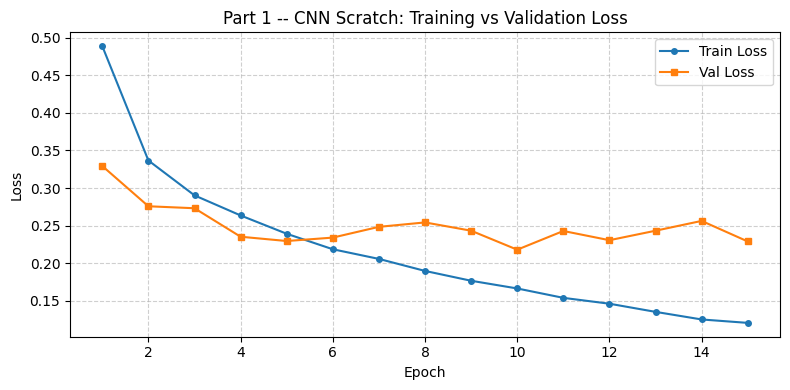

In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_p1["train_loss"], label="Train Loss", marker="o", markersize=4)
plt.plot(epochs_range, history_p1["val_loss"],   label="Val Loss",   marker="s", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 1 -- CNN Scratch: Training vs Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("part1_loss_curve.png", dpi=150)
plt.show()

In [ ]:
test_acc_metric = keras.metrics.SparseCategoricalAccuracy()

for x_b, y_b in test_ds:
    logits = cnn_model(x_b, training=False)
    test_acc_metric.update_state(y_b, logits)

cnn_test_acc = test_acc_metric.result().numpy()
print(f"CNN (Part 1) Test Accuracy: {cnn_test_acc:.4f}  ({cnn_test_acc*100:.2f}%)")

CNN (Part 1) Test Accuracy: 0.9205  (92.05%)


## 1.5 Comparison with HW1 MLP Baseline

In [ ]:
mlp_test_acc    = 0.8778
mlp_param_count = 203530

cnn_param_count = cnn_model.count_params()

print("\n" + "="*55)
print(f"{'Model':<28} {'Test Acc':>10} {'#Params':>12}")
print("-"*55)
print(f"{'MLP (HW 1)':<28} {mlp_test_acc:>10.4f} {mlp_param_count:>12,}")
print(f"{'CNN from Scratch (Part 1)':<28} {cnn_test_acc:>10.4f} {cnn_param_count:>12,}")
print("="*55)


Model                          Test Acc      #Params
-------------------------------------------------------
MLP (HW 1)                       0.8778      203,530
CNN from Scratch (Part 1)        0.9205      421,930


### Discussion -- CNN vs MLP

While my baseline MLP model from the previous homework achieved a test accuracy of 87.78% with 203,530 parameters, the CNN model built from scratch in this assignment reached a test accuracy of 92.05% with 421,930 parameters. Although the parameter count is roughly doubled, the CNN's ability to capture spatial relationships through shared convolutional filters provides a clear advantage. Furthermore, its hierarchical feature extraction makes it inherently better suited for image datasets like Fashion-MNIST, leading to higher generalization performance compared to the flat structure of an MLP.

---
# Part 2 -- Global Average Pooling (GAP)

## 2.1 GAP Model Architecture

In [ ]:
def build_cnn_gap(input_shape=(28, 28, 1), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # GAP head -- Flatten and Dense(128) removed
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes)(x)   # logits -- no softmax

    return keras.Model(inputs, outputs, name="CNN_GAP")

gap_model = build_cnn_gap()
gap_model.summary()

Model: "CNN_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,754 (77.16 KB)

 Trainable params: 19,562 (76.41 KB)

 Non-trainable params: 192 (768.00 B)

## 2.2 Training the GAP Model

In [ ]:
from tensorflow import keras
import tensorflow as tf

optimizer_gap    = keras.optimizers.Adam(learning_rate=1e-3)
train_loss_gap_m = keras.metrics.Mean()
val_loss_gap_m   = keras.metrics.Mean()
val_acc_gap_m    = keras.metrics.SparseCategoricalAccuracy()

@tf.function
def train_step_gap(x_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = gap_model(x_batch, training=True)
        loss   = loss_fn(y_batch, logits)
    grads = tape.gradient(loss, gap_model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
    optimizer_gap.apply_gradients(zip(grads, gap_model.trainable_variables))
    train_loss_gap_m.update_state(loss)

@tf.function
def val_step_gap(x_batch, y_batch):
    logits = gap_model(x_batch, training=False)
    loss   = loss_fn(y_batch, logits)
    val_loss_gap_m.update_state(loss)
    val_acc_gap_m.update_state(y_batch, logits)

history_p2 = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    train_loss_gap_m.reset_state()
    for x_b, y_b in train_ds:
        train_step_gap(x_b, y_b)

    val_loss_gap_m.reset_state()
    val_acc_gap_m.reset_state()
    for x_b, y_b in val_ds:
        val_step_gap(x_b, y_b)

    t_loss = train_loss_gap_m.result().numpy()
    v_loss = val_loss_gap_m.result().numpy()
    v_acc  = val_acc_gap_m.result().numpy()

    history_p2["train_loss"].append(t_loss)
    history_p2["val_loss"].append(v_loss)

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train_loss={t_loss:.4f}  val_loss={v_loss:.4f}  val_acc={v_acc:.4f}")

Epoch  1/15  train_loss=0.9659  val_loss=0.7872  val_acc=0.7636
Epoch  2/15  train_loss=0.6537  val_loss=0.7564  val_acc=0.7189
Epoch  3/15  train_loss=0.5580  val_loss=0.6703  val_acc=0.7610
Epoch  4/15  train_loss=0.4988  val_loss=0.5986  val_acc=0.7909
Epoch  5/15  train_loss=0.4595  val_loss=0.5311  val_acc=0.8075
Epoch  6/15  train_loss=0.4303  val_loss=0.5325  val_acc=0.8098
Epoch  7/15  train_loss=0.4126  val_loss=0.6913  val_acc=0.7656
Epoch  8/15  train_loss=0.3939  val_loss=0.5404  val_acc=0.8048
Epoch  9/15  train_loss=0.3777  val_loss=0.5746  val_acc=0.8071
Epoch 10/15  train_loss=0.3651  val_loss=0.4420  val_acc=0.8479
Epoch 11/15  train_loss=0.3518  val_loss=0.3921  val_acc=0.8613
Epoch 12/15  train_loss=0.3445  val_loss=0.5205  val_acc=0.8098
Epoch 13/15  train_loss=0.3358  val_loss=0.5292  val_acc=0.8150
Epoch 14/15  train_loss=0.3260  val_loss=0.4417  val_acc=0.8478
Epoch 15/15  train_loss=0.3229  val_loss=0.4275  val_acc=0.8465


## 2.3 Model Summary Comparison & Test Accuracy

In [ ]:
print("\n" + "="*60)
print("CNN SCRATCH (Part 1) Summary")
print("="*60)
cnn_model.summary()

print("\n" + "="*60)
print("CNN GAP (Part 2) Summary")
print("="*60)
gap_model.summary()


CNN SCRATCH (Part 1) Summary


Model: "CNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,930 (1.61 MB)

 Trainable params: 421,738 (1.61 MB)

...

Model: "CNN_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,754 (77.16 KB)

 Trainable params: 19,562 (76.41 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
cnn_total     = cnn_model.count_params()
cnn_trainable = sum([tf.size(v).numpy() for v in cnn_model.trainable_variables])
cnn_non_train = cnn_total - cnn_trainable

gap_total     = gap_model.count_params()
gap_trainable = sum([tf.size(v).numpy() for v in gap_model.trainable_variables])
gap_non_train = gap_total - gap_trainable

# GAP test accuracy
gap_test_metric = keras.metrics.SparseCategoricalAccuracy()
for x_b, y_b in test_ds:
    logits = gap_model(x_b, training=False)
    gap_test_metric.update_state(y_b, logits)
gap_test_acc = gap_test_metric.result().numpy()

print("\n" + "="*70)
print(f"{'Model':<20} {'Total':>10} {'Trainable':>12} {'Non-Train':>12} {'Test Acc':>10}")
print("-"*70)
print(f"{'CNN Scratch':<20} {cnn_total:>10,} {cnn_trainable:>12,} {cnn_non_train:>12,} {cnn_test_acc:>10.4f}")
print(f"{'CNN GAP':<20} {gap_total:>10,} {gap_trainable:>12,} {gap_non_train:>12,} {gap_test_acc:>10.4f}")
print("="*70)


Model                     Total    Trainable    Non-Train   Test Acc
----------------------------------------------------------------------
CNN Scratch             421,930      421,738          192     0.9205
CNN GAP                  19,754       19,562          192     0.8522


### Discussion -- GAP vs Flatten

Replacing the Flatten and Dense(128) layers with GlobalAveragePooling2D drastically reduced the total parameter count from 421,930 to just 19,754. However, this massive reduction in model capacity significantly hurt generalization in this specific run, causing the test accuracy to drop from 92.05% to 85.22%. While GAP acts as a strong regularizer and creates a much lighter model, removing the large Dense layer discarded too much representational power needed to classify the Fashion-MNIST dataset effectively.

---
# Part 3 -- Transfer Learning with MobileNetV2

## 3.1 Preprocessing (96x96, 3-channel)

In [ ]:
IMG_SIZE = 96

def preprocess_for_mobilenet(image, label):
    # Resize: (28, 28, 1) -> (96, 96, 1)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Replicate grayscale channel: (96, 96, 1) -> (96, 96, 3)
    image = tf.repeat(image, 3, axis=-1)
    # Scale back to [0, 255] before MobileNetV2 preprocessing
    image = image * 255.0
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

tl_train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
               .shuffle(50000, seed=42)
               .map(preprocess_for_mobilenet, num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE)
               .prefetch(AUTOTUNE))

tl_val_ds   = (tf.data.Dataset.from_tensor_slices((x_val, y_val))
               .map(preprocess_for_mobilenet, num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE)
               .prefetch(AUTOTUNE))

tl_test_ds  = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
               .map(preprocess_for_mobilenet, num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE)
               .prefetch(AUTOTUNE))

print("MobileNetV2 pipeline ready.")

MobileNetV2 pipeline ready.


## 3.2 Feature Extraction (Frozen Base)

In [ ]:
# Load MobileNetV2 without the top classification head
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False   # Freeze all base layers

# Add custom classification head
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(10)(x)   # logits -- no softmax

mobilenet_model = keras.Model(inputs, outputs, name="MobileNetV2_TL")

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("\n--- Feature Extraction (Frozen Base) -- 5 Epochs ---")
history_frozen = mobilenet_model.fit(
    tl_train_ds,
    epochs=5,
    validation_data=tl_val_ds,
    verbose=1
)

frozen_test_loss, frozen_test_acc = mobilenet_model.evaluate(tl_test_ds, verbose=0)
print(f"\n[Frozen] Test Accuracy: {frozen_test_acc:.4f}  ({frozen_test_acc*100:.2f}%)")


--- Feature Extraction (Frozen Base) -- 5 Epochs ---
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 43ms/step - accuracy: 0.8001 - loss: 0.5825 - val_accuracy: 0.8709 - val_loss: 0.3538
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 19ms/step - accuracy: 0.8548 - loss: 0.4016 - val_accuracy: 0.8827 - val_loss: 0.3186
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8615 - loss: 0.3801 - val_accuracy: 0.8865 - val_loss: 0.3157
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.8639 - loss: 0.3784 - val_accuracy: 0.8868 - val_loss: 0.3133
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8657 - loss: 0.3723 - val_accuracy: 0.8842 - val_loss: 0.3249

[Frozen] Test Accuracy: 0.8748  (87.48%)


## 3.3 Fine-Tuning (Last 20 Layers Unfrozen)

In [ ]:
# Unfreeze the base model, then re-freeze all layers except the last 20
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Total base layers  : {len(base_model.layers)}")
print(f"Trainable layers   : {trainable_count}  (last 20 unfrozen)")

# Recompile with a low learning rate
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

print("\n--- Fine-Tuning -- 5 Epochs ---")
history_finetune = mobilenet_model.fit(
    tl_train_ds,
    epochs=5,
    validation_data=tl_val_ds,
    verbose=1
)

finetune_test_loss, finetune_test_acc = mobilenet_model.evaluate(tl_test_ds, verbose=0)
print(f"\n[Fine-Tuned] Test Accuracy: {finetune_test_acc:.4f}  ({finetune_test_acc*100:.2f}%)")

Total base layers  : 154
Trainable layers   : 20  (last 20 unfrozen)

--- Fine-Tuning -- 5 Epochs ---
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 41ms/step - accuracy: 0.7932 - loss: 0.7205 - val_accuracy: 0.8896 - val_loss: 0.3306
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8545 - loss: 0.4598 - val_accuracy: 0.8931 - val_loss: 0.3091
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8706 - loss: 0.3883 - val_accuracy: 0.8969 - val_loss: 0.2912
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8813 - loss: 0.3428 - val_accuracy: 0.9012 - val_loss: 0.2758
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8916 - loss: 0.3068 - val_accuracy: 0.9035 - val_loss: 0.2662

[Fine-Tuned] Test Accuracy: 0.9016  (90.16%)


## 3.4 Final Comparison Table -- All Models


Model                               Test Accuracy
--------------------------------------------------
MLP (HW 1)                                0.8778
CNN from Scratch (Part 1)                 0.9205
MobileNetV2 -- Frozen                     0.8748
MobileNetV2 -- Fine-Tuned                 0.9016


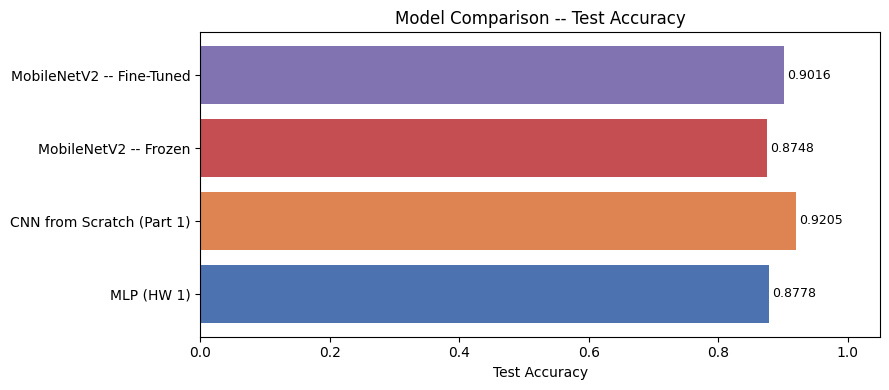

In [ ]:
# mlp_test_acc was defined in Part 1
results = [
    ("MLP (HW 1)",                  mlp_test_acc),
    ("CNN from Scratch (Part 1)",    cnn_test_acc),
    ("MobileNetV2 -- Frozen",        frozen_test_acc),
    ("MobileNetV2 -- Fine-Tuned",    finetune_test_acc),
]

print("\n" + "="*50)
print(f"{'Model':<35} {'Test Accuracy':>12}")
print("-"*50)
for name, acc in results:
    print(f"{name:<35} {acc:>12.4f}")
print("="*50)

# Bar chart
names  = [r[0] for r in results]
accs   = [r[1] for r in results]
colors = ["#4c72b0", "#dd8452", "#c44e52", "#8172b2"]

plt.figure(figsize=(9, 4))
bars = plt.barh(names, accs, color=colors)
plt.xlabel("Test Accuracy")
plt.title("Model Comparison -- Test Accuracy")
plt.xlim(0, 1.05)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{acc:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150)
plt.show()

### Discussion -- Transfer Learning Effectiveness

Transfer learning from ImageNet provides a noticeable benefit on Fashion-MNIST, with the fine-tuned MobileNetV2 reaching 90.16% test accuracy compared to 87.48% for the frozen base. However, this is still slightly lower than the 92.05% achieved by our from-scratch CNN. The benefit is smaller than expected likely due to the significant domain gap between natural color photographs and low-resolution grayscale clothing items, as well as the interpolation artifacts introduced when upsampling 28x28 images to 96x96 to fit the pretrained model's inputs.

## 3.5 MobileNetV2 Training Curves

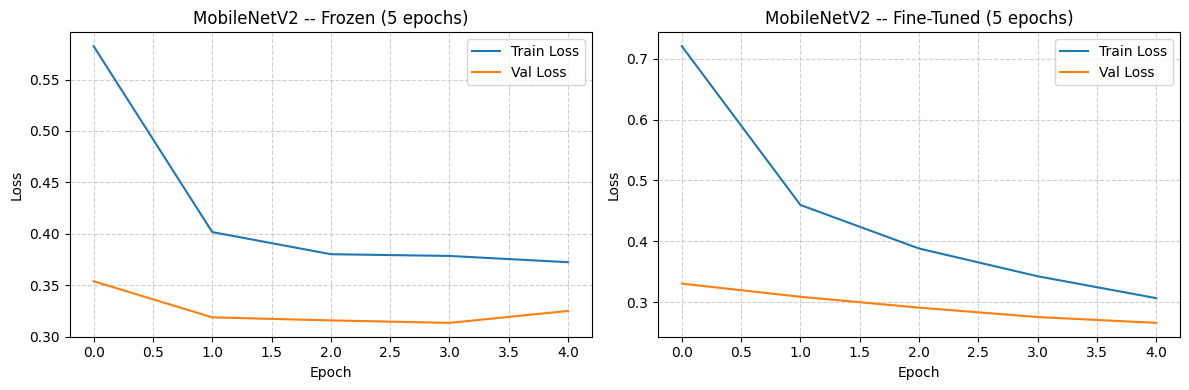

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_frozen.history["loss"],     label="Train Loss")
axes[0].plot(history_frozen.history["val_loss"], label="Val Loss")
axes[0].set_title("MobileNetV2 -- Frozen (5 epochs)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(history_finetune.history["loss"],     label="Train Loss")
axes[1].plot(history_finetune.history["val_loss"], label="Val Loss")
axes[1].set_title("MobileNetV2 -- Fine-Tuned (5 epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("part3_loss_curves.png", dpi=150)
plt.show()